# 01 — ARIMA / ARIMAX Baseline

Auto-select the ARIMA order, run a rolling-window ablation ladder of ARIMAX variants over
public-information groups, pick the best by RMSE and WDA, then stress-test the efficiency null
with Diebold-Mariano (vs the drift floor), ex-2025 robustness, and Pesaran-Timmermann.

### Roadmap

| § | Step | What happens |
|---|---|---|
| 1 | Load features | Read **only** the silver target (+ `split`) from `features_weekly.csv`; build the train+val refit sample. The exogenous columns are read later in §4, where the ladder uses them (pure ARIMA needs none). |
| 2 | Order selection (AIC) | Grid-search $(p,0,q)$ on train+val. AIC picks $(0,0,0)$ — weekly silver returns have no usable linear autocorrelation, so ARIMAX reduces to OLS on lagged regressors. |
| 3 | Forecast schemes + walk-forward | `recursive_forecast` (expanding) and `rolling_forecast` (last 100w), both refit every step. Run pure **ARIMA** with each window — the weak-form baseline; §3.1 plots expanding (= drift) vs rolling. |
| 4 | Ablation ladder | ARIMAX ladder run in **both windows** (expanding + rolling): rung 0 = 6 cross-asset returns (the incremental baseline), then each public-info group (GS / FRED-daily / COT / sentiment / …) + the BestLag filter rungs. |
| 5 | Evaluate | One table — RMSE / MAE / DA / WDA for Naïve, Drift, ARIMA (both windows), every ARIMAX rung. Save `metrics_arima.csv`. |
| 6 | Sub-period robustness | Pick the best ARIMAX by **RMSE** (primary, magnitude) and **WDA** (secondary, directional); break both down by `PERIODS`; save period + preds CSVs (WDA-best under legacy names, RMSE-best alongside). |
| 7 | Predicted vs actual | Full-window plot: best ARIMA vs best ARIMAX. |
| 8 | Diebold-Mariano | Incremental (vs the ARIMAX-returns base) + the load-bearing **vs-Drift floor** (OOS R² + DM, squared & absolute error). 8b: ex-2025 robustness. 8c: Pesaran-Timmermann directional lens. |
| 9 | 2026 zoom | Actual vs best variant on the 2026 YTD slice. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load the silver target

In [2]:
# ARIMA needs only the silver target, so read just that column (+ the split labels). The
# exogenous columns are read later in §4, where the ablation ladder actually uses them.
TARGET = 'silver_return'
silver = pd.read_csv('../../data/processed/features_weekly.csv',
                     index_col='week_end', parse_dates=True, usecols=['week_end', 'split', TARGET])

# Weekly target per split (already W-FRI-summed in the frame).
def _y(name): return silver.loc[silver['split'] == name, TARGET].dropna()
y_train, y_val, y_test = _y('train'), _y('val'), _y('test')
# Refit on train+val before predicting test (val already used for AIC selection),
# so walk-forward starts end-2022 rather than end-2021.
y_train_full = pd.concat([y_train, y_val]).sort_index()

print(f'Weekly train: {len(y_train)} weeks | val: {len(y_val)} | '
      f'train+val: {len(y_train_full)} | test: {len(y_test)}')

Weekly train: 365 weeks | val: 52 | train+val: 417 | test: 174


### Why aggregate to weekly?

**Log returns are additive**, so summing 5 daily log-returns gives the exact weekly log-return:

$$\log\frac{P_5}{P_1} = \log\frac{P_2}{P_1} + \log\frac{P_3}{P_2} + \log\frac{P_4}{P_3} + \log\frac{P_5}{P_4}$$

No approximation is involved — this is exact. The same applies to the exogenous market returns.

**Sentiment** is aggregated with `.mean()` instead of `.sum()` — we want the average mood
over the week, not an accumulated score. Sentiment values are bounded in $[-1, 1]$ so summing
them would produce an unbounded number with no clear interpretation.

**Shape after aggregation:**

| Split | Daily | Weekly |
|-------|-------|--------|
| Train | 1 755 rows | ~351 weeks |
| Test  |   500 rows | ~100 weeks |

The 100-week test set is the binding constraint — it is enough for a meaningful evaluation
but directional accuracy estimates will have wider confidence intervals than the daily version.
See `03b_arima_daily.ipynb` for the 1-day-ahead version on the full daily sample.

TODO: remove the daily mention if we don't get to the daily part.

## 2. Order selection via AIC grid search

In [3]:
best_aic, best_order = np.inf, (1, 0, 1)
results = []

# AIC selection on train+val combined — val is part of "selection data",
# not test, so it's appropriate to include here. With (0,0,0) winning by a
# wide margin the order is robust to whether val is included, but using the
# combined sample is the cleaner methodological choice.
for p in range(0, 6):
    for q in range(0, 6):
        try:
            m = ARIMA(y_train_full, order=(p, 0, q)).fit()
            results.append({'p': p, 'q': q, 'aic': m.aic, 'bic': m.bic})
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, 0, q)
        except Exception:
            pass

results_df = pd.DataFrame(results).sort_values('aic').head(10)
print(f'Best ARIMA order (weekly, train+val): {best_order}  AIC: {best_aic:.2f}')
results_df

Best ARIMA order (weekly, train+val): (0, 0, 0)  AIC: -1533.42


,p,q,aic,bic
0,0,0,-1533.424232,-1525.358060
1,0,1,-1531.610018,-1519.510759
6,1,0,-1531.606538,-1519.507280
7,1,1,-1531.334543,-1515.202198
14,2,2,-1530.130913,-1505.932395
24,4,0,-1529.848070,-1505.649553
4,0,4,-1529.668537,-1505.470019
2,0,2,-1529.663834,-1513.531489
12,2,0,-1529.637864,-1513.505520
3,0,3,-1528.598482,-1508.433051


> **Note — ARIMAX(0,0,0) is OLS regression**
>
> Because the AIC search selects order (0,0,0), the ARIMAX model below reduces to
> ordinary least squares on lagged exogenous variables.  This is expected for weekly
> silver returns — there is almost no linear autocorrelation once noise is factored in.
> The value of ARIMAX here is the formal framework for testing whether macro covariates
> add predictive power, not the AR/MA terms themselves.

## 3. Forecast schemes — motivation

**Train+val refit before testing.** Val (2022) is used implicitly via AIC order
selection on the combined sample (see cell above). Once the order is chosen,
walk-forward starts from `y_train_full = train + val` so that week 1 of the
test set (early Jan 2023) sees the full preceding history including 2022 —
not just up to end-2021. This matches the standard ML pattern (train → val for
selection → refit on train+val before test).

Two approaches for generating 1-step-ahead out-of-sample forecasts:

**Expanding window (recursive)**  — trains on *all* available history up to week *t*.
- Pros: uses maximum data; asymptotically efficient.
- Cons: old regimes (pre-2021 silver squeeze) have equal weight as recent ones.

**Rolling window (100 weeks ≈ 2 years)** — trains on the *most recent* 100 weeks only.
- Pros: adapts faster to regime changes; silver has had at least two distinct volatility regimes.
- Cons: discards long-run information.

Both windows are carried through the whole notebook — pure **ARIMA** (§3.1) and every **ARIMAX rung** (§4) is run expanding *and* rolling. The next cell prepares the walk-forward functions implementing both scenarios; we then run ARIMA under each and compare them in §3.1. Because the expanding ARIMA *is* the drift, every variant is judged against that single floor (§8) regardless of window; the secondary *incremental* test stays window-matched (rolling vs ARIMAX-rolling, expanding vs ARIMAX-expanding).

## 3. Walk-forward forecast functions

In [4]:
def recursive_forecast(y_train, y_test, order, exog_train=None, exog_test=None):
    """Expanding-window 1-step-ahead forecast."""
    history = list(y_train)
    preds   = []
    exog_h  = list(exog_train.values) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
    return np.array(preds)


def rolling_forecast(y_train, y_test, order, window_size=100,
                     exog_train=None, exog_test=None):
    """Fixed-window 1-step-ahead forecast (most recent window_size weeks)."""
    history = list(y_train[-window_size:])
    preds   = []
    exog_h  = list(exog_train.values[-window_size:]) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        history.pop(0)
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
            exog_h.pop(0)
    return np.array(preds)

In [5]:
print('Running ARIMA expanding window (weekly, train+val refit)...')
preds_arima_exp = recursive_forecast(y_train_full, y_test, best_order)
print('Running ARIMA rolling window (100 weeks)...')
preds_arima_rol = rolling_forecast(y_train_full, y_test, best_order, window_size=100)
print('Done')

Running ARIMA expanding window (weekly, train+val refit)...
Running ARIMA rolling window (100 weeks)...
Done


### 3.1 ARIMA: rolling vs expanding window

ARIMA(0,0,0) predicts the conditional mean, so this contrasts the two windows directly:

- **Expanding** — the prevailing (all-history) mean: a stable, slowly-drifting line. This **is the
  drift** (Welch-Goyal historical average = ARIMA(0,0,0)), so it is our **main baseline / EMH floor**.
- **Rolling (100w)** — a 2-year mean that chases recent regimes, so it is jumpier (and, being a
  shorter sample, can even edge the expanding mean on RMSE for pure window reasons — not predictability).

Every later model is judged against the drift (= expanding ARIMA), so both windows are carried
through the ablation ladder below.

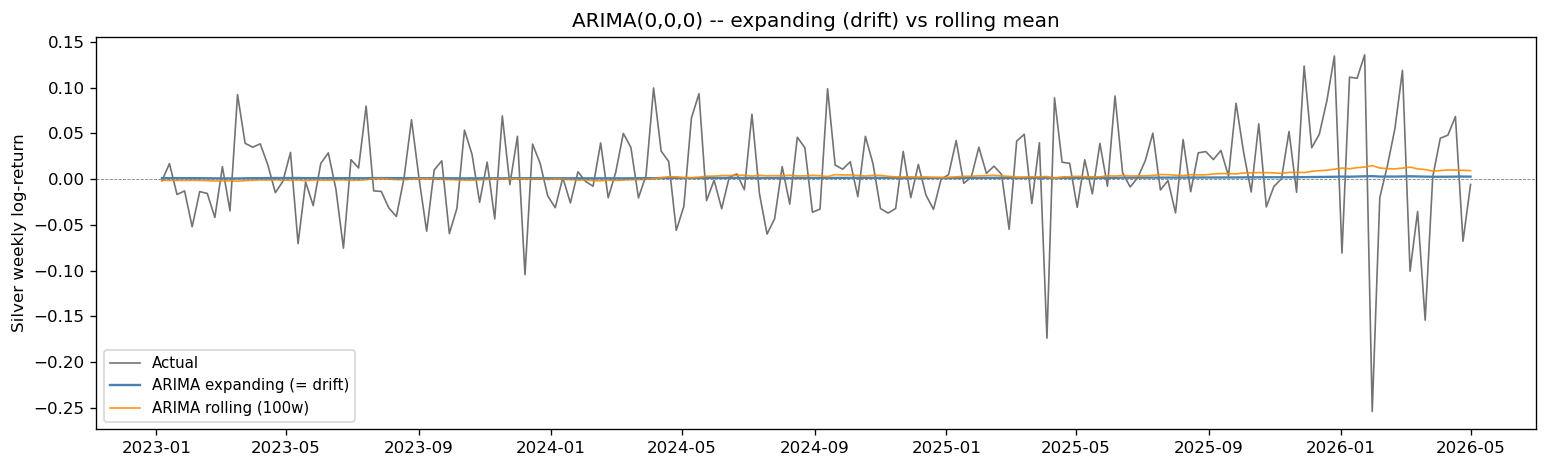

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(y_test.index, y_test.values,   label='Actual',                    lw=1,   color='black', alpha=0.55)
ax.plot(y_test.index, preds_arima_exp, label='ARIMA expanding (= drift)', lw=1.4, color='steelblue')
ax.plot(y_test.index, preds_arima_rol, label='ARIMA rolling (100w)',      lw=1,   color='darkorange', alpha=0.9)
ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.set_title('ARIMA(0,0,0) -- expanding (drift) vs rolling mean')
ax.set_ylabel('Silver weekly log-return')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Ablation ladder (ARIMAX, both windows)

**ARIMAX = ARIMA(0,0,0) + lagged exogenous regressors** — with order (0,0,0) it is OLS on the
lagged exog. Rung 0 is the returns-only baseline (the 6 cross-asset returns `gold, usd, copper,
sp500, vix, oil`); each higher rung adds one **public-information group**, read from
`feature_groups.json` so the ladder tracks the feature set automatically.

**Look-ahead discipline.** At week *t* we don't know this week's exog until it closes, so every
exogenous column is lagged 1 week (`.shift(1)`) before entering the model.

**Windows.** Each rung is run **both** expanding and rolling-100w (suffix `expanding` / `rolling (100w)`).

Rungs on top of the 6 returns: **GS** (gold/silver ratio), **FRED_daily** (Δreal-rate, Δbreakeven,
Δjobless-claims), **COT** (managed-money + commercial net positioning), **Reddit / News /
Sentiment**, **Macro+COT**, **GS+Sentiment**, **ALL** (kitchen sink). Each is a semi-strong-form
test: does that public channel beat the returns-only baseline?

**BestLag rungs** (filter screen, `02_features` §8b) — the filter counterpart to `02c`'s embedded
RF/LASSO selection. Each predictor enters at its train+val `|corr|`-maximising lag (pre-materialised,
so **no** extra `.shift(1)`); standalone exog (the ARIMA order supplies the AR base). `BestLag-All`
⊇ `BestLag-Sig90` (`p<0.10`) ⊇ `BestLag-Sig` (`p<0.05`). **Caveat:** the screen's strong
correlations are largely *test-period artefacts*, so read these as an optimistic upper bound, not a
clean OOS feature set.

In [7]:
import json

# Exog read is deferred to here (only the silver target was read in §1). Pull ONLY the columns the
# ablation ladder needs. Every one is already weekly-aggregated in the frame (returns /
# Delta-changes -> sum, levels / net-% positioning -> last, sentiment -> mean); we just .shift(1)
# it (the 1-week look-ahead lag).
with open('../../data/processed/feature_groups.json') as f:
    GROUPS = json.load(f)

ret_cols      = ['gold_return', 'usd_return', 'copper_return',
                 'sp500_return', 'vix_return', 'oil_return']   # returns-only ARIMAX baseline
ABLATION_COLS = GROUPS['YF_DAILY'] + GROUPS['FRED_DAILY'] + GROUPS['GS'] + GROUPS['COT'] + GROUPS['SENT']
NEED_COLS     = list(dict.fromkeys(ABLATION_COLS + GROUPS['BESTLAG_ALL']))
exog = pd.read_csv('../../data/processed/features_weekly.csv',
                   index_col='week_end', parse_dates=True, usecols=['week_end'] + NEED_COLS)

all_feat_lag  = exog[ABLATION_COLS].shift(1).fillna(0)   # Asier: check this fillna is sensible

def make_exog(extra):
    cols = ret_cols + [c for c in extra if c in all_feat_lag.columns]
    return all_feat_lag.loc[y_train_full.index, cols], all_feat_lag.loc[y_test.index, cols]

WINDOWS = ('rolling (100w)', 'expanding')

def run_window(window, X_tr, X_te):
    if window == 'rolling (100w)':
        return rolling_forecast(y_train_full, y_test, best_order, window_size=100,
                                exog_train=X_tr, exog_test=X_te)
    return recursive_forecast(y_train_full, y_test, best_order, exog_train=X_tr, exog_test=X_te)

# Both windows for every rung. Rung 0 (label '') = ARIMAX returns-only, naming
# 'ARIMAX rolling (100w)' / 'ARIMAX expanding' to match the DM / saved-preds conventions.
# 'ARIMAX expanding' (returns-only, expanding) coincides with the drift+exog incremental base.
all_candidates = {}
LADDER = [
    ('',              []),
    ('+GS',           GROUPS['GS']),
    ('+FRED_daily',   GROUPS['FRED_DAILY']),
    ('+COT',          GROUPS['COT']),
    ('+Reddit',       ['reddit_sentiment']),
    ('+News',         ['news_sentiment']),
    ('+Sentiment',    GROUPS['SENT']),
    ('+Macro+COT',    GROUPS['FRED_DAILY'] + GROUPS['COT']),
    ('+GS+Sentiment', GROUPS['GS'] + GROUPS['SENT']),
    ('+ALL',          GROUPS['GS'] + GROUPS['FRED_DAILY'] + GROUPS['COT'] + GROUPS['SENT']),
]
for label, extra in LADDER:
    X_tr, X_te = make_exog(extra)
    for window in WINDOWS:
        name = f'ARIMAX{label} {window}'
        print(f'Running {name}...')
        all_candidates[name] = run_window(window, X_tr, X_te)

# -- BestLag rungs (filter screen, 02_features §8b), both windows ------------------
# These columns are ALREADY pre-lagged at each feature's train+val |corr|-max lag, so they get
# NO extra .shift(1) (that would double-lag them). Standalone exog (the ARIMA order supplies the
# AR base), mirroring the tree BestLag rungs in 04/05. Members include monthly-macro levels, so
# ffill/bfill the warmup rather than fillna(0) (a 0 would be a wild outlier). Optimistic filter
# probe -- the screen's correlations are largely test-period artefacts (see the §8b caveat).
bestlag_lvl = exog[GROUPS['BESTLAG_ALL']].ffill().bfill()
BESTLAG_LADDER = [
    ('BestLag-All',   GROUPS['BESTLAG_ALL']),
    ('BestLag-Sig90', GROUPS['BESTLAG_SIG90']),
    ('BestLag-Sig',   GROUPS['BESTLAG_SIG']),
]
for label, cols in BESTLAG_LADDER:
    X_tr = bestlag_lvl.loc[y_train_full.index, cols]
    X_te = bestlag_lvl.loc[y_test.index,       cols]
    for window in WINDOWS:
        name = f'{label} {window}'
        print(f'Running {name}...')
        all_candidates[name] = run_window(window, X_tr, X_te)

print(f'\nBuilt {len(all_candidates)} ARIMAX variants ({len(WINDOWS)} windows).')

Running ARIMAX rolling (100w)...
Running ARIMAX expanding...
Running ARIMAX+GS rolling (100w)...
Running ARIMAX+GS expanding...
Running ARIMAX+FRED_daily rolling (100w)...
Running ARIMAX+FRED_daily expanding...
Running ARIMAX+COT rolling (100w)...
Running ARIMAX+COT expanding...
Running ARIMAX+Reddit rolling (100w)...
Running ARIMAX+Reddit expanding...
Running ARIMAX+News rolling (100w)...
Running ARIMAX+News expanding...
Running ARIMAX+Sentiment rolling (100w)...
Running ARIMAX+Sentiment expanding...
Running ARIMAX+Macro+COT rolling (100w)...
Running ARIMAX+Macro+COT expanding...
Running ARIMAX+GS+Sentiment rolling (100w)...
Running ARIMAX+GS+Sentiment expanding...
Running ARIMAX+ALL rolling (100w)...
Running ARIMAX+ALL expanding...
Running BestLag-All rolling (100w)...
Running BestLag-All expanding...
Running BestLag-Sig90 rolling (100w)...
Running BestLag-Sig90 expanding...
Running BestLag-Sig rolling (100w)...
Running BestLag-Sig expanding...

Built 26 ARIMAX variants (2 windows).


## 5. Evaluate

One table — RMSE / MAE / DA / WDA for the benchmarks, pure ARIMA (both windows), and every
ARIMAX rung (both windows). Two benchmark rows:

- **Naïve (`r_{t-1}`)** — persistence. Weak reference for a return target (high RMSE); kept for
  context, *not* the efficiency benchmark.
- **Drift (prevailing mean)** — expanding historical mean = random-walk-with-drift = **ARIMA(0,0,0)**
  by construction. The **correct EMH floor** for a return target (Welch-Goyal / Campbell-Thompson).
  Its sign stays positive, so directionally it is the **always-up** line and its WDA = the
  magnitude-weighted up-share (≈0.59 full-sample, ≈0.49 ex-2025 — the rest is the 2025 bull).

**Primary metric = RMSE / DM-vs-Drift (magnitude); WDA is the secondary directional lens.**

**Metric definitions** — click to expand. RMSE / MAE score the conditional **mean** (the magnitude axis the EMH claim lives on) and OOS R² is the effect size on that same axis vs the Drift floor; DA / WDA are the **directional** read. Significance for all of these sits in §8. Full standalone reference: [`tests.md`](tests.md).

<details>
<summary>&nbsp;<b>RMSE / MAE</b> &nbsp; <code>Descriptive</code> <code>Magnitude</code> &nbsp;— point-forecast error, the primary descriptive metric</summary>

| | |
|---|---|
| **RMSE** | $\sqrt{\tfrac{1}{n}\sum_i (y_i-\hat y_i)^2}$ |
| **MAE** | $\tfrac{1}{n}\sum_i \lvert y_i-\hat y_i\rvert$ |
| **Why primary** | The efficiency claim is about the conditional mean; RMSE / MAE measure how far forecasts sit from it. |
| **Caveat** | Weekly returns carry ~5%/wk innovation variance that dominates RMSE — every model (incl. Drift) collapses onto roughly the unconditional std, so RMSE *alone* barely separates models. This is exactly why OOS R² + DM sit on top of it (§8). |
| **Load-bearing?** | No — rank and describe only. |

</details>

<details>
<summary>&nbsp;<b>OOS R²</b> — Campbell–Thompson (2008) &nbsp; <code>Effect size</code> <code>Magnitude</code> &nbsp;— how much does the model beat the random walk?</summary>

| | |
|---|---|
| **Formula** | $R^2_{OS}=1-\dfrac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y_i)^2}$ &nbsp; (benchmark $\bar y_i$ = the prevailing-mean / Drift forecast) |
| **What it answers** | The **effect size** on the magnitude axis — % reduction in OOS squared error vs the random walk; the standard return-predictability number. Shown as the `r2_os` column in the table below. |
| **How to read** | $>0$ ⇒ beats Drift OOS; $\le 0$ (the usual return result) ⇒ worse than just predicting the prevailing mean. Drift's own value is 0 by construction. |
| **Pairs with** | DM (§8) — effect size still needs a significance test; a small positive R² can be noise. |
| **Load-bearing?** | The effect-size half of the floor test — its significance is the DM-vs-Drift test in §8. |

</details>

<details>
<summary>&nbsp;<b>DA</b> — directional accuracy &nbsp; <code>Descriptive</code> <code>Direction</code> &nbsp;— naïve sign hit-rate</summary>

| | |
|---|---|
| **Formula** | $\tfrac{1}{n}\sum_i \mathbf{1}\!\left[\operatorname{sign}(y_i)=\operatorname{sign}(\hat y_i)\right]$ |
| **Caveat** | Blind to the base rate — in an up-market "always up" scores high while saying nothing. Does not adjust for the unconditional up-frequency. |
| **Load-bearing?** | No. WDA is the better directional descriptive; PT (§8b) is its significance test. |

</details>

<details>
<summary>&nbsp;<b>WDA</b> — weighted DA &nbsp; <code>Descriptive</code> <code>Direction</code> &nbsp;— the secondary directional lens</summary>

| | |
|---|---|
| **Formula** | $\dfrac{\sum_i \lvert y_i\rvert \cdot \mathbf{1}\!\left[\operatorname{sign}(y_i)=\operatorname{sign}(\hat y_i)\right]}{\sum_i \lvert y_i\rvert}$ |
| **Why better than DA** | Credits getting the sign right on the weeks that *moved* and ignores chop — a coin-flip on a 0.01% week is irrelevant; a correct call on a 5% week matters. |
| **`best_name` usage** | The notebook flags the WDA-argmax variant as "best", but that is **descriptive display only** — the verdict rests on DM-vs-Drift (§8), not the noisy, bull-inflated WDA ranking. |
| **Load-bearing?** | No — secondary descriptive. PT is its significance partner. |

</details>

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, oos_r2, PERIODS

actuals    = y_test.values
test_index = y_test.index

# Naïve (persistence): this week = last week's return.
naive_pred = np.concatenate([[np.nan], actuals[:-1]])

# Drift / random-walk-with-drift: prevailing (expanding) mean of past returns (Welch-Goyal).
# No look-ahead -- at week t it averages all returns observed before t. The mean stays positive,
# so directionally it is an 'always-up' call. This IS ARIMA(0,0,0) by construction, so
# 'beat the drift' = the weak-form test.
_hist = list(y_train_full.values)
drift_pred = np.empty(len(actuals))
for _t in range(len(actuals)):
    drift_pred[_t] = np.mean(_hist)
    _hist.append(float(actuals[_t]))

# Single table: benchmarks + pure ARIMA (both windows) + every ARIMAX rung.
eval_preds = {
    'Naive (t-1 week)':        naive_pred,
    'Drift (prevailing mean)': drift_pred,
    'ARIMA expanding':         preds_arima_exp,
    'ARIMA rolling (100w)':    preds_arima_rol,
    **all_candidates,
}
metrics = [evaluate(name, actuals, pred) for name, pred in eval_preds.items()]

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
# OOS R^2 vs the Drift floor (Campbell-Thompson 2008) -- effect size; >0 beats the random walk OOS.
# Drift is the benchmark so its own R2_OS is 0 by construction. Shown alongside RMSE/MAE/DA/WDA;
# its significance is the DM-vs-Drift test in section 8.
metrics_df['r2_os'] = [oos_r2(actuals, eval_preds[m], drift_pred) * 100 for m in metrics_df['model']]
metrics_df = metrics_df[['model', 'rmse', 'mae', 'r2_os', 'dir_acc', 'wda']]   # r2_os shown next to the error metrics
metrics_df.to_csv('../../data/processed/metrics_arima.csv', index=False)

# Drift WDA by period: Drift's sign is always positive, so this is the Drift / ARIMA(0,0,0)
# directional line -- the WDA to beat.
print('\nDrift WDA by period (directional benchmark to beat):')
for _lbl, (_a, _b) in PERIODS.items():
    _s = y_test.loc[_a:_b]
    if len(_s):
        _au = np.sum(np.abs(_s.values) * (_s.values > 0)) / np.sum(np.abs(_s.values))
        print(f'  {_lbl:20s} WDA={_au:.3f}  (n={len(_s)})')

metrics_df

Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
Drift (prevailing mean)                        RMSE=0.05190  MAE=0.03714  DA=0.557  WDA=0.588
ARIMA expanding                                RMSE=0.05190  MAE=0.03714  DA=0.557  WDA=0.588
ARIMA rolling (100w)                           RMSE=0.05174  MAE=0.03690  DA=0.557  WDA=0.573
ARIMAX rolling (100w)                          RMSE=0.05323  MAE=0.03765  DA=0.523  WDA=0.483
ARIMAX expanding                               RMSE=0.05220  MAE=0.03683  DA=0.569  WDA=0.555
ARIMAX+GS rolling (100w)                       RMSE=0.05450  MAE=0.03767  DA=0.580  WDA=0.573
ARIMAX+GS expanding                            RMSE=0.05200  MAE=0.03670  DA=0.598  WDA=0.606
ARIMAX+FRED_daily rolling (100w)               RMSE=0.05371  MAE=0.03787  DA=0.557  WDA=0.512
ARIMAX+FRED_daily expanding                    RMSE=0.05236  MAE=0.03695  DA=0.580  WDA=0.521
ARIMAX+COT rolling (100w)                      RMSE=0.05468 

,model,rmse,mae,r2_os,dir_acc,wda
0,Naive (t-1 week),0.075941,0.053966,-112.857285,0.491329,0.489862
1,Drift (prevailing mean),0.051902,0.037135,0.000000,0.557471,0.587779
2,ARIMA expanding,0.051903,0.037135,-0.001813,0.557471,0.587779
3,ARIMA rolling (100w),0.051745,0.036896,0.606302,0.557471,0.572523
4,ARIMAX rolling (100w),0.053226,0.037650,-5.166460,0.522989,0.482664
5,ARIMAX expanding,0.052196,0.036835,-1.135784,0.568966,0.554856
6,ARIMAX+GS rolling (100w),0.054500,0.037675,-10.262602,0.580460,0.573317
7,ARIMAX+GS expanding,0.052001,0.036703,-0.380822,0.597701,0.605666
8,ARIMAX+FRED_daily rolling (100w),0.053707,0.037866,-7.074915,0.557471,0.511996
9,ARIMAX+FRED_daily expanding,0.052360,0.036949,-1.771855,0.580460,0.521206


## 6. Sub-period robustness + best-variant selection

Pick the best ARIMAX two ways — by **RMSE** (primary, magnitude — §3a) and by **WDA** (secondary,
directional) — and break each down by calendar year to check the result isn't driven by one regime.

**Saved for cross-model use:** WDA-best keeps the legacy filenames (`period_arimax_weekly.csv`,
`preds_arimax_best_weekly.csv`) so `evaluation.ipynb` is untouched; RMSE-best is saved alongside
(`period_arimax_rmse_weekly.csv`, `preds_arimax_bestrmse_weekly.csv`).

With order (0,0,0) expect the two picks to differ: RMSE-best tends to be the *timid* variant
(closest to the drift — extra features add variance that hurts RMSE), WDA-best a directional bettor.

In [9]:
def _best_by_wda(candidates, actuals):
    return max(candidates, key=lambda k:
        np.nansum(np.abs(actuals) * (np.sign(actuals) == np.sign(candidates[k]))) /
        np.nansum(np.abs(actuals)))

def _best_by_rmse(candidates, actuals):
    return min(candidates, key=lambda k:
        np.sqrt(np.nanmean((actuals - candidates[k]) ** 2)))

def _period_r2(pred):
    # OOS R^2 vs the Drift floor, per calendar sub-period (Campbell-Thompson) -- the effect-size
    # companion to the per-period error metrics. oos_r2 masks NaN internally.
    drift_s, pred_s = pd.Series(drift_pred, index=test_index), pd.Series(pred, index=test_index)
    r2 = {}
    for _lbl, (_a, _b) in PERIODS.items():
        _y, _p, _d = y_test.loc[_a:_b].values, pred_s.loc[_a:_b].values, drift_s.loc[_a:_b].values
        if len(_y):
            r2[_lbl] = oos_r2(_y, _p, _d) * 100
    return r2

def _show_period(pred, csv):
    res = period_metrics(actuals, pred, test_index, PERIODS)   # RMSE / MAE / DA / WDA per period
    r2  = _period_r2(pred)
    res['R2_OS'] = [r2.get(lbl, np.nan) for lbl in res.index]   # effect size vs Drift (display only)
    display(res[['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']].style
            .format({'n': '{:.0f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2_OS': '{:+.2f}',
                     'DA': '{:.3f}', 'WDA': '{:.3f}'})
            .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))
    res[['n', 'DA', 'WDA']].to_csv(csv)   # legacy schema saved -- evaluation.ipynb reads these

def _save_preds(pred, csv):
    pd.DataFrame({'actual': actuals, 'predicted': pred}, index=test_index) \
      .rename_axis('Date').to_csv(csv)

# -- Pure ARIMA (no exog) -----------------------------------------------------
arima_only      = {'ARIMA expanding': preds_arima_exp, 'ARIMA rolling (100w)': preds_arima_rol}
best_arima_name = _best_by_wda(arima_only, actuals)     # WDA-best (legacy: feeds period_arima)
best_arima_rmse = _best_by_rmse(arima_only, actuals)
print(f'Best ARIMA  -- WDA: {best_arima_name}  |  RMSE: {best_arima_rmse}')
_show_period(arima_only[best_arima_name], '../../data/processed/period_arima_weekly.csv')

# -- Best ARIMAX -- by WDA (directional) and RMSE (magnitude, primary) --------
best_arimax_name = _best_by_wda(all_candidates, actuals)
best_arimax_rmse = _best_by_rmse(all_candidates, actuals)
best_pred        = all_candidates[best_arimax_name]
best_pred_rmse   = all_candidates[best_arimax_rmse]
print(f'\nBest ARIMAX -- WDA: {best_arimax_name}  |  RMSE: {best_arimax_rmse}')
print('\nWDA-best by period:')
_show_period(best_pred,      '../../data/processed/period_arimax_weekly.csv')
print('RMSE-best by period:')
_show_period(best_pred_rmse, '../../data/processed/period_arimax_rmse_weekly.csv')

# -- Save winning predictions for cross-model DM in evaluation.ipynb ----------
# Legacy names = WDA-best (evaluation.ipynb untouched); RMSE-best saved alongside.
_save_preds(arima_only[best_arima_name], '../../data/processed/preds_arima_best_weekly.csv')
_save_preds(arima_only[best_arima_rmse], '../../data/processed/preds_arima_bestrmse_weekly.csv')
_save_preds(best_pred,                   '../../data/processed/preds_arimax_best_weekly.csv')
_save_preds(best_pred_rmse,              '../../data/processed/preds_arimax_bestrmse_weekly.csv')
print('\nSaved: arima/arimax period + preds (WDA-best legacy names, RMSE-best alongside).')

Best ARIMA  -- WDA: ARIMA expanding  |  RMSE: ARIMA rolling (100w)


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0400,0.0318,+0.00,0.481,0.492
2024 (bull start),52,0.0380,0.0299,-0.00,0.500,0.570
2025 (bull run),52,0.0499,0.0352,-0.01,0.692,0.757
2026 (YTD),18,0.1003,0.0791,+0.00,0.556,0.498
── Full test ──,174,0.0519,0.0371,-0.00,0.557,0.588



Best ARIMAX -- WDA: ARIMAX+Macro+COT rolling (100w)  |  RMSE: ARIMAX+GS+Sentiment expanding

WDA-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0405,0.0321,-2.70,0.615,0.612
2024 (bull start),52,0.0431,0.0320,-28.94,0.615,0.551
2025 (bull run),52,0.0470,0.0340,+11.04,0.673,0.798
2026 (YTD),18,0.1136,0.0870,-28.23,0.556,0.488
── Full test ──,174,0.0552,0.0383,-12.99,0.626,0.624


RMSE-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0389,0.0301,+5.41,0.692,0.664
2024 (bull start),52,0.0366,0.0284,+7.35,0.615,0.691
2025 (bull run),52,0.0507,0.0358,-3.34,0.596,0.583
2026 (YTD),18,0.1016,0.0804,-2.54,0.389,0.395
── Full test ──,174,0.0518,0.0365,+0.23,0.609,0.588



Saved: arima/arimax period + preds (WDA-best legacy names, RMSE-best alongside).


## 7. Predicted vs actual — best ARIMA vs best ARIMAX

Full test window, best variant per family, **two panels**:

- **Top — WDA-best** (directional pick): the variant that calls the most sign, magnitude-weighted.
- **Bottom — RMSE-best** (magnitude pick): the variant with the lowest squared error — which, at
  order (0,0,0), is the *timid* one that stays closest to the drift.

ARIMA(0,0,0) is a near-flat line at the conditional mean (≈ the weekly drift); the rolling ARIMAX
moves week-to-week as the lagged exog regressors shift.

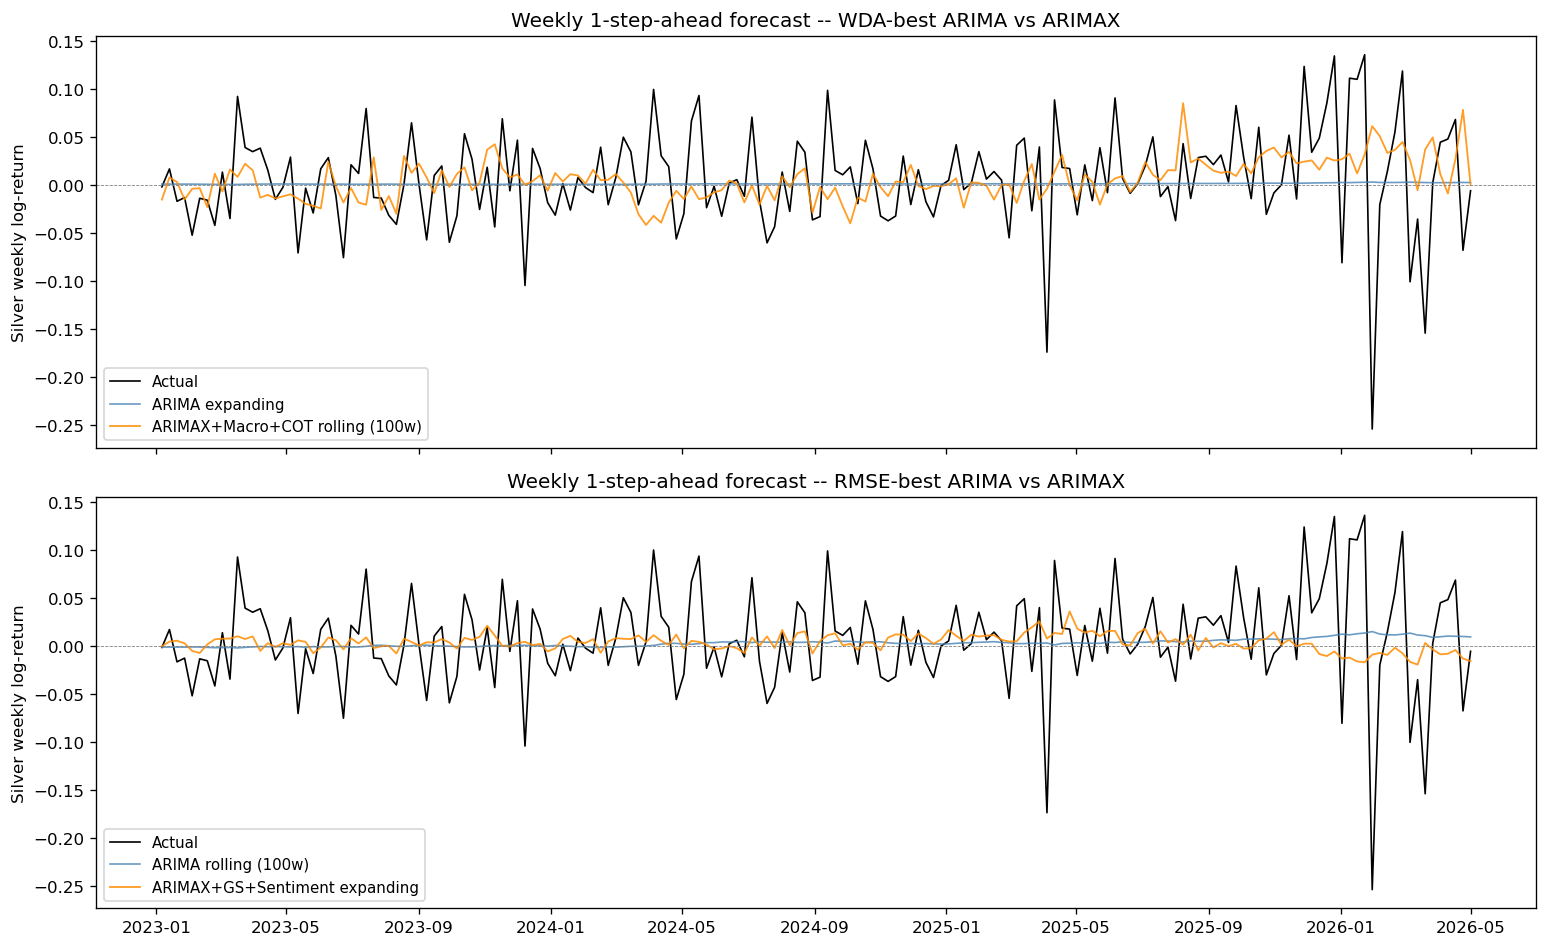

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
panels = [('WDA-best',  best_arima_name, best_arimax_name, best_pred),
          ('RMSE-best', best_arima_rmse, best_arimax_rmse, best_pred_rmse)]
for ax, (tag, aname, xname, xpred) in zip(axes, panels):
    ax.plot(test_index, actuals,           label='Actual', lw=1,   color='black')
    ax.plot(test_index, arima_only[aname], label=aname,    lw=1,   alpha=0.8,  color='steelblue')
    ax.plot(test_index, xpred,             label=xname,    lw=1.1, alpha=0.85, color='darkorange')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_title(f'Weekly 1-step-ahead forecast -- {tag} ARIMA vs ARIMAX')
    ax.set_ylabel('Silver weekly log-return')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Significance tests

The descriptive metrics in §5 rank the models; this section asks whether the differences are
**statistically real**. Three tests, all against the **Drift** floor (= ARIMA(0,0,0), the random
walk — so the cross-asset EXOG is on trial too). The DM-vs-Drift floor is the load-bearing
efficiency verdict; PT is the secondary directional lens. Full reference: [`tests.md`](tests.md).

| Test | Asks | Axis | Role |
|---|---|---|---|
| **DM — squared error** (§8) | Does *any* model beat the random walk? | magnitude | **load-bearing** |
| **DM — absolute error** (§8) | …and does that survive heavy tails? | magnitude | robustness |
| **Pesaran–Timmermann** (§8b) | Do the *sign* calls beat chance? | direction | secondary |

Each test is explained in detail, then run. **Effect size** lives with §5: OOS R² (Campbell–Thompson)
is the % MSE reduction vs Drift and is already in the §5 metrics table — the DM tests below supply its
significance. §8c then re-runs the whole battery with the 2025 bull removed.

# Asier: understand the comment of Newest-West

### Diebold–Mariano vs Drift — squared-error floor (the load-bearing test)

The headline efficiency test: under squared-error loss (which the conditional mean minimises), can
any model beat the Drift? Expand for the formula and the Newey–West detail.

<details>
<summary>&nbsp;<b>Diebold–Mariano</b> (squared error) &nbsp; <code>Significance</code> <code>Magnitude</code> &nbsp;— does any model beat the random walk?</summary>

| | |
|---|---|
| **H₀** | Equal predictive accuracy — the two error series have the same expected loss. |
| **What it answers** | Is the gap in forecast accuracy between a model and Drift statistically significant? |
| **Statistic** | $d_t=\text{loss}(\text{Drift})-\text{loss}(\text{model})$, &nbsp; $\text{DM}=\dfrac{\bar d}{\sqrt{(\gamma_0+2\gamma_1)/n}}\sim N(0,1)$ |
| **Sign convention** | `pred1` = Drift always. **Positive** DM ⇒ model beats Drift (evidence against efficiency); **negative** ⇒ Drift wins. |
| **Why Newey–West lag-1** | The loss differences $d_t$ are autocorrelated (volatility clustering, overlapping info). The naïve variance ignores that → understates it → *overstates* significance. The HAC variance $\gamma_0+2\gamma_1$ adds the lag-1 autocovariance to correct for first-order serial correlation — enough for a 1-week-ahead forecast. |
| **Floor vs incremental** | Only the **floor** test (model vs Drift) runs in the aligned trio. The incremental DM (variant vs ARIMAX base) was dropped — covariates are public info, so the floor already puts the base on trial, and incremental can mislead (a variant beats EXOG while EXOG loses to Drift). |
| **Effect size** | The companion OOS R² (% MSE reduction vs Drift) is in the §5 table; DM supplies its significance. |
| **Finding** | Never DM-significant for any public-info model; feature-rich / rolling variants are significantly *worse*. |
| **Load-bearing?** | **Yes — the primary verdict.** |

</details>

In [11]:
# Weak + semi-strong floor vs the Drift (prevailing-mean / random walk = ARIMA(0,0,0), the own-history
# floor -- so the cross-asset EXOG is on trial too). THIS is the load-bearing efficiency test.
# Effect size (OOS R^2) is reported in the section-5 metrics table; here DM gives its significance.
weak_set = {
    'ARIMA expanding':      preds_arima_exp,
    'ARIMA rolling (100w)': preds_arima_rol,
    **all_candidates,
}
print('Diebold-Mariano -- vs Drift floor   [squared error]')
print('Weak + semi-strong test: can any model beat the no-predictability drift?')
print('-' * 95)
for name, pred in weak_set.items():
    diebold_mariano(actuals, drift_pred, pred, 'Drift', name)

Diebold-Mariano -- vs Drift floor   [squared error]
Weak + semi-strong test: can any model beat the no-predictability drift?
-----------------------------------------------------------------------------------------------
Drift                                    vs ARIMA expanding                           DM=-1.348  p=0.178  (ns)  -> winner: tie
Drift                                    vs ARIMA rolling (100w)                      DM=+0.336  p=0.737  (ns)  -> winner: tie
Drift                                    vs ARIMAX rolling (100w)                     DM=-2.039  p=0.041  *     -> winner: Drift
Drift                                    vs ARIMAX expanding                          DM=-1.026  p=0.305  (ns)  -> winner: tie
Drift                                    vs ARIMAX+GS rolling (100w)                  DM=-1.895  p=0.058  (ns)  -> winner: tie
Drift                                    vs ARIMAX+GS expanding                       DM=-0.135  p=0.893  (ns)  -> winner: tie
Drift          

### Diebold–Mariano vs Drift — absolute-error loss (robustness)

The same DM test against the same floor, but with loss $\lvert y-\hat y\rvert$ instead of $(y-\hat y)^2$. Expand for why we repeat it.

<details>
<summary>&nbsp;<b>Diebold–Mariano</b> (absolute error) &nbsp; <code>Significance</code> <code>Magnitude</code> &nbsp;— robustness of the floor test to fat tails</summary>

| | |
|---|---|
| **Why repeat under `ae`** | Returns are heavy-tailed, so a few extreme weeks dominate the squared loss and inflate its variance → squared-error DM is low-powered. Absolute-error loss down-weights those tails. |
| **Same machinery** | Identical statistic / sign convention / Newey–West as the squared-error version above — only `loss='ae'` changes. |
| **Status** | Robustness only — **squared error stays the headline**. A real improvement should survive both. |

</details>

In [12]:
# Robustness -- floor test under ABSOLUTE-error loss (heavy-tailed returns -> squared-error DM is
# low-powered; |error| more robust). Squared error (above) stays the headline.
print('Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]')
print('-' * 95)
for name, pred in weak_set.items():
    diebold_mariano(actuals, drift_pred, pred, 'Drift', name, loss='ae')

Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]
-----------------------------------------------------------------------------------------------
Drift                                    vs ARIMA expanding                           DM=-0.915  p=0.360  (ns)  -> winner: tie
Drift                                    vs ARIMA rolling (100w)                      DM=+0.753  p=0.452  (ns)  -> winner: tie
Drift                                    vs ARIMAX rolling (100w)                     DM=-0.766  p=0.444  (ns)  -> winner: tie
Drift                                    vs ARIMAX expanding                          DM=+1.019  p=0.308  (ns)  -> winner: tie
Drift                                    vs ARIMAX+GS rolling (100w)                  DM=-0.624  p=0.533  (ns)  -> winner: tie
Drift                                    vs ARIMAX+GS expanding                       DM=+0.826  p=0.409  (ns)  -> winner: tie
Drift                                    vs ARIMAX+FRED_daily rolling (1

## 8b. Pesaran–Timmermann — directional test (secondary lens)

The DM tests above are **magnitude** tests; WDA / DA are **directional** descriptives, so their
significance needs a directional test. Expand for the detail.

<details>
<summary>&nbsp;<b>Pesaran–Timmermann</b> (PT) &nbsp; <code>Significance</code> <code>Direction</code> &nbsp;— do the sign calls beat chance?</summary>

| | |
|---|---|
| **H₀** | Predicted and actual signs are independent — no market-timing skill — *accounting for the unconditional up-rate*. |
| **Key subtlety** | Nets out the base rate: "always up in an up-market" does **not** pass. This is what separates PT from raw DA. |
| **Output** | `skill` (significant, PT > 0 — genuine timing) · `perverse` (significant, PT < 0 — systematically wrong signs, still information) · `tie` (chance). |
| **Drift degenerate** | A constant-sign forecast → PT returns `n/a`; a built-in sanity check, not a bug. |
| **Heavy caveats** | (a) the best-by-WDA variant is the max over ~12 ablations, so its p-value is selection-biased / optimistic; (b) the one apparent signal (ARIMA COT-positioning) does **not** replicate in RF (1/38 ≈ chance), XGB (0/38) or LSTM (0/15). |
| **Finding** | Treat as a non-replicating footnote — an adaptive-markets aside (Lo 2004); it does not touch the magnitude-efficiency verdict. |
| **Load-bearing?** | No — secondary directional lens only. |

</details>

In [13]:
from eval_utils import pesaran_timmermann

# Directional (secondary) lens — Pesaran-Timmermann market-timing test on the SIGN calls,
# run across ALL variants to size the selection / multiple-testing picture. DM-vs-drift
# stays the primary (magnitude) efficiency test; PT only asks whether the sign beats chance.
print('Pesaran-Timmermann directional test — full test window')
print('H0: predicted & actual signs independent (no timing skill)  |  * p<0.05  ** p<0.01  *** p<0.001')
print('-' * 95)
pesaran_timmermann(actuals, drift_pred,      name='Drift (always-up)')   # degenerate ref
pesaran_timmermann(actuals, preds_arima_exp, name='ARIMA expanding')     # degenerate ref
pt_results = {n: pesaran_timmermann(actuals, p, name=n) for n, p in all_candidates.items()}

# Multiple-testing picture (rough — the variants are correlated, so chance is a heuristic).
_tested = [r for r in pt_results.values() if not np.isnan(r['p'])]
_sig    = {n: r for n, r in pt_results.items() if not np.isnan(r['p']) and r['p'] < 0.05}
print(f'\n{len(_sig)}/{len(_tested)} variants significant at p<0.05 '
      f'(~{0.05 * len(_tested):.1f} expected by chance under H0): {list(_sig)}')

# Per-period PT for the best-by-WDA variant — is the full-window result driven by one regime?
print(f'\nPer-period PT — {best_arimax_name}:')
_bp = pd.Series(best_pred, index=test_index)
for _lbl, (_a, _b) in PERIODS.items():
    _yy = y_test.loc[_a:_b].values
    _pp = _bp.loc[_a:_b].values
    if len(_yy) >= 12:
        pesaran_timmermann(_yy, _pp, name=f'  {_lbl}  (n={len(_yy)})')

Pesaran-Timmermann directional test — full test window
H0: predicted & actual signs independent (no timing skill)  |  * p<0.05  ** p<0.01  *** p<0.001
-----------------------------------------------------------------------------------------------
Drift (always-up)                         DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
ARIMA expanding                           DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
ARIMAX rolling (100w)                     DA=0.523  DA|indep=0.510  PT=+0.354  p=0.724  (ns)  -> winner: tie (chance)
ARIMAX expanding                          DA=0.569  DA|indep=0.514  PT=+1.512  p=0.131  (ns)  -> winner: tie (chance)
ARIMAX+GS rolling (100w)                  DA=0.580  DA|indep=0.515  PT=+1.802  p=0.071  (ns)  -> winner: tie (chance)
ARIMAX+GS expanding                       DA=0.598  DA|indep=0.526  PT=+2.138  p=0.033  *     -> winner: ARIMAX+GS expanding
ARIMAX+FRED_daily rolling (1

## 8c. Robustness — drop the 2025 bull run (full battery)

2025 carries the entire always-up line (its WDA ≈0.59 full-sample vs ≈0.49 without it), so once the
full-window tests are done, re-run **the whole battery** — metrics + OOS R² + DM floor (se/ae) + PT —
on **2023 + 2024 + 2026** only. Evaluation-only (models unchanged, still trained walk-forward through
2025); pooled (per-year DM is underpowered). The efficiency conclusion *strengthens* once the bull is gone.

In [14]:
from eval_utils import pesaran_timmermann
# Full battery on the non-bull window. Evaluation-only (forecasts unchanged); pooled for DM power.
mask_ex25 = np.asarray(test_index.year != 2025)
a_ex      = actuals[mask_ex25]
drift_ex  = drift_pred[mask_ex25]
au_ex     = np.sum(np.abs(a_ex) * (a_ex > 0)) / np.sum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  always-up WDA = {au_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
evaluate('Drift (prevailing mean)', a_ex, drift_ex)
for name, pred in weak_set.items():
    evaluate(name, a_ex, np.asarray(pred)[mask_ex25])

print('\nOOS R^2 vs Drift (2025 excluded) -- >0 beats the random walk:')
print('-' * 95)
for name, pred in weak_set.items():
    _r2 = oos_r2(a_ex, np.asarray(pred)[mask_ex25], drift_ex) * 100
    print(f'  {name:40s} R2_OS = {_r2:+6.2f}%   -> winner: {name if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 95)
for name, pred in weak_set.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 95)
for name, pred in weak_set.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name, loss='ae')

print('\nPesaran-Timmermann (2025 excluded) -- directional sign test:')
print('-' * 95)
for name, pred in all_candidates.items():
    pesaran_timmermann(a_ex, np.asarray(pred)[mask_ex25], name=name)

Ex-2025 sample: 122 weeks  |  always-up WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
Drift (prevailing mean)                        RMSE=0.05275  MAE=0.03796  DA=0.500  WDA=0.520
ARIMA expanding                                RMSE=0.05275  MAE=0.03796  DA=0.500  WDA=0.520
ARIMA rolling (100w)                           RMSE=0.05310  MAE=0.03799  DA=0.500  WDA=0.498
ARIMAX rolling (100w)                          RMSE=0.05531  MAE=0.03954  DA=0.467  WDA=0.394
ARIMAX expanding                               RMSE=0.05307  MAE=0.03758  DA=0.590  WDA=0.547
ARIMAX+GS rolling (100w)                       RMSE=0.05616  MAE=0.03890  DA=0.541  WDA=0.512
ARIMAX+GS expanding                            RMSE=0.05276  MAE=0.03740  DA=0.582  WDA=0.600
ARIMAX+FRED_daily rolling (100w)               RMSE=0.05585  MAE=0.03943  DA=0.516  WDA=0.432
ARIMAX+FRED_daily expanding                    RMSE=0.05322  MAE=0.03759  DA=0.582  WDA=0.495
ARIMAX+COT rolling (100w)                      RMSE

## 9. 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample slice. Shows the **drift floor** plus both winners (WDA-best and RMSE-best); the RMSE-best line hugs the drift — minimising squared error just reproduces the random walk — while the WDA-best is the directional bettor.

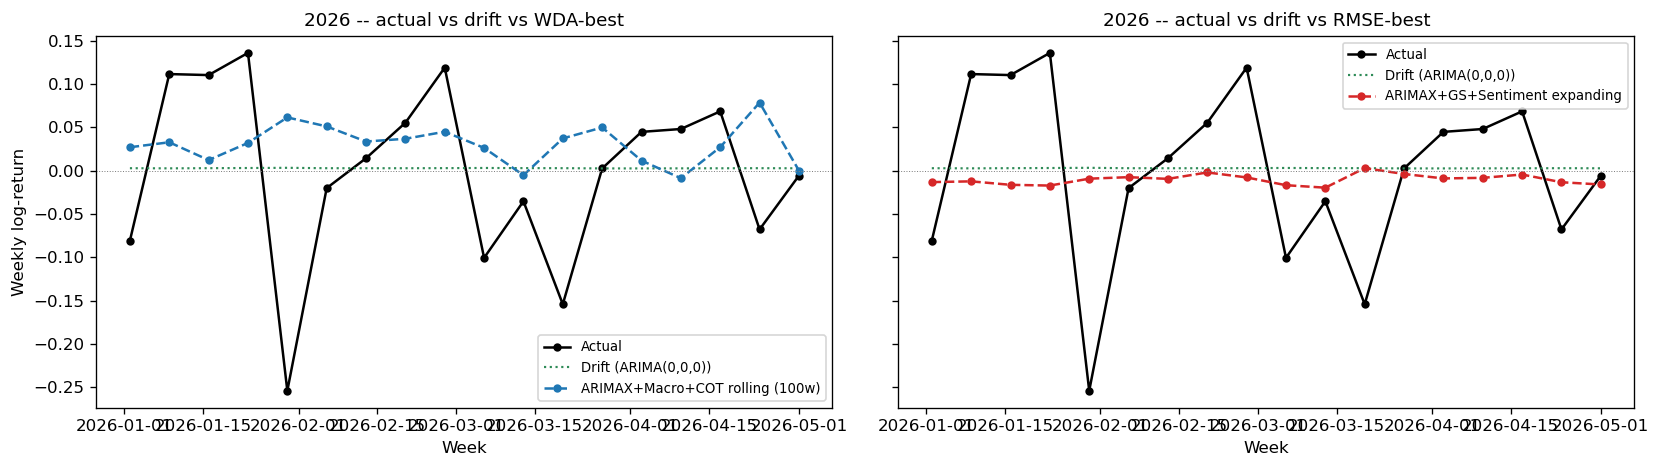

In [15]:
df26 = pd.DataFrame({'actual': actuals, 'drift': drift_pred,
                     'wda_best': best_pred, 'rmse_best': best_pred_rmse},
                    index=test_index).loc['2026':]

if df26.empty:
    print('No 2026 data in test set yet.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
    panels = [('wda_best', best_arimax_name, '#1f77b4', 'WDA-best'),
              ('rmse_best', best_arimax_rmse, '#d62728', 'RMSE-best')]
    for ax, (col, vname, color, tag) in zip(axes, panels):
        ax.plot(df26.index, df26['actual'], color='black',    lw=1.5, marker='o', ms=4, label='Actual')
        ax.plot(df26.index, df26['drift'],  color='seagreen', lw=1.3, ls=':',  label='Drift (ARIMA(0,0,0))')
        ax.plot(df26.index, df26[col],      color=color,      lw=1.5, marker='o', ms=4, ls='--', label=vname)
        ax.axhline(0, color='grey', lw=0.6, ls=':')
        ax.set_title(f'2026 -- actual vs drift vs {tag}', fontsize=11)
        ax.set_xlabel('Week')
        ax.legend(fontsize=8)
    axes[0].set_ylabel('Weekly log-return')
    plt.tight_layout()
    plt.show()

## 10. Generalised Spectral Test (Hong & Lee 2003) — a nonlinear weak-form check

The drift floor (§8) and white-noise residuals show no *linear* own-history signal. But
"white noise" only rules out **linear autocorrelation** — a series can be serially uncorrelated
yet still have a **nonlinear** conditional mean. This test closes that gap.

**What it tests.** The martingale-difference (MDS) hypothesis

$$H_0:\quad \mathbb{E}[\,r_t \mid r_{t-1}, r_{t-2}, \dots\,] = \text{const}$$

against **linear *and* nonlinear** alternatives. Instead of autocovariances it uses the empirical
characteristic function

$$\sigma_j(v) = \operatorname{Cov}\!\big(r_t,\; e^{\,i v\, r_{t-j}}\big),$$

which is zero at every lag $j\ge 1$ and every $v$ **iff** returns are an MDS. Sweeping $v$ probes
*all* nonlinear functions of the past, so a flat-autocorrelation-but-predictable series — which
Ljung-Box misses — still shows up.

**How it's computed.** $|\hat\sigma_j(v)|^2$ is summed over lags with a Bartlett kernel and
integrated over $v$ with a Gaussian weight (closed form $e^{-d^2/2}$). The $p$-value comes from a
**wild bootstrap** (Rademacher) that imposes the null and is robust to volatility clustering — the
asymptotic null is non-pivotal here, so the bootstrap is the standard route (Escanciano & Velasco 2006).

The first code cell validates the implementation on synthetic series; the second runs it on silver.
Outcome: **fail to reject MDS** (mean unpredictable, even nonlinearly) while squared returns are
strongly dependent — one coherent statement: *the mean is a martingale, the variance is not.*

In [16]:
# ── Generalised spectral derivative test of the MDS hypothesis (Hong & Lee 2003) ──
from numpy.random import default_rng
from statsmodels.stats.diagnostic import acorr_ljungbox

def generalized_spectral_test(Y, p=10, B=999, seed=0):
    """MDS test  H0: E[Y_t | Y_{t-1}, ...] = const,  vs linear AND nonlinear alternatives.

    Uses the empirical characteristic function sigma_j(v) = Cov(Y_t, exp(i v Y_{t-j})),
    aggregated over lags j<p with a Bartlett kernel and integrated over v with a Gaussian
    weight (closed form exp(-d^2/2)). Diagonal (t=s) dropped -> degenerate U-statistic.
    p-value via a wild (Rademacher) bootstrap that imposes the null and is robust to
    volatility clustering. One-sided: reject MDS for a large statistic.
    """
    Y = np.asarray(Y, float); Y = Y[np.isfinite(Y)]
    n = len(Y)
    Z = (Y - Y.mean()) / Y.std(ddof=0)              # standardise so the Gaussian ECF weight resolves
    E = default_rng(seed).choice([-1.0, 1.0], size=(n, B))   # shared multipliers across lags
    Q_obs, Q_boot = 0.0, np.zeros(B)
    for j in range(1, p):                            # Bartlett kernel zeros j >= p
        w = (1.0 - j / p) ** 2
        m = n - j
        Zr, Zc = Z[j:], Z[:m]                        # regressand Y_t ; conditioner Y_{t-j}
        d = Zc[:, None] - Zc[None, :]
        G = np.exp(-0.5 * d * d); np.fill_diagonal(G, 0.0)
        Q_obs  += w * (Zr @ G @ Zr) / m
        D = Zr[:, None] * E[j:]                       # wild-perturbed regressand (m x B)
        Q_boot += w * (D * (G @ D)).sum(0) / m
    pval = (1.0 + np.sum(Q_boot >= Q_obs)) / (B + 1.0)
    return dict(stat=Q_obs, pval=pval, n=n, p=p, B=B)

# Sanity check: pass iid, flag linear AR(1), AND flag a nonlinear white-noise series
# that Ljung-Box (linear-only) misses.
_rng = default_rng(0); _N = 600
_iid = _rng.standard_normal(_N)
_ar1 = np.zeros(_N)
for _t in range(1, _N): _ar1[_t] = 0.3 * _ar1[_t - 1] + _rng.standard_normal()
_e = _rng.standard_normal(_N); _nlin = _e.copy(); _nlin[1:] = _e[1:] + 0.8 * _e[:-1] ** 2
print('Validation (lags=10):  Ljung-Box vs generalised-spectral p-values')
print('-' * 64)
for _name, _s in [('iid noise (is MDS)', _iid), ('AR(1) (linear dep)', _ar1),
                  ('nonlin white noise (NOT MDS)', _nlin)]:
    _lb = acorr_ljungbox(_s, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    _gs = generalized_spectral_test(_s, p=10, B=299, seed=1)['pval']
    print(f'  {_name:30s}  LB p={_lb:.3f}   GS p={_gs:.3f}')
print('\n^ LB misses the nonlinear case (p large); GS catches it (p small) -- the whole point.')

Validation (lags=10):  Ljung-Box vs generalised-spectral p-values
----------------------------------------------------------------
  iid noise (is MDS)              LB p=0.702   GS p=0.943
  AR(1) (linear dep)              LB p=0.000   GS p=0.007
  nonlin white noise (NOT MDS)    LB p=0.770   GS p=0.013

^ LB misses the nonlinear case (p large); GS catches it (p small) -- the whole point.


In [17]:
# Apply to the full weekly silver-return series (train+val+test -- this is a
# property-of-the-series test, so all data is used, unlike the OOS forecasts above).
full_returns = pd.concat([y_train_full, y_test]).sort_index()
print(f'Generalised spectral MDS test -- weekly silver returns (n={len(full_returns)} weeks)')
print(f'{"lag order p":>12s}  {"GS stat":>9s}  {"boot p":>7s}   verdict')
print('-' * 60)
for _p in (5, 10, 20):
    _r = generalized_spectral_test(full_returns.values, p=_p, B=999, seed=42)
    _v = 'reject MDS (predictable)' if _r['pval'] < 0.05 else 'fail to reject -> MDS holds'
    print(f'{_p:12d}  {_r["stat"]:9.3f}  {_r["pval"]:7.3f}   {_v}')

# Contrast with Ljung-Box: returns (linear mean) vs squared returns (variance).
_lb_r  = acorr_ljungbox(full_returns,      lags=[10], return_df=True)['lb_pvalue'].iloc[0]
_lb_r2 = acorr_ljungbox(full_returns ** 2, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
print(f'\nLjung-Box(10)  returns          p={_lb_r:.3f}   (linear own-history autocorrelation)')
print(f'Ljung-Box(10)  squared returns   p={_lb_r2:.3f}   (volatility clustering -> vol chapter)')
print('\nVerdict: returns are a martingale difference even against nonlinear alternatives'
      '\n(GS fails to reject at every lag order), yet the variance is strongly dependent.'
      '\nWeak-form efficiency holds in the conditional MEAN; the action is in the variance.')

Generalised spectral MDS test -- weekly silver returns (n=591 weeks)
 lag order p    GS stat   boot p   verdict
------------------------------------------------------------
           5     -0.873    0.971   fail to reject -> MDS holds
          10     -1.714    0.914   fail to reject -> MDS holds
          20     -3.592    0.908   fail to reject -> MDS holds

Ljung-Box(10)  returns          p=0.065   (linear own-history autocorrelation)
Ljung-Box(10)  squared returns   p=0.000   (volatility clustering -> vol chapter)

Verdict: returns are a martingale difference even against nonlinear alternatives
(GS fails to reject at every lag order), yet the variance is strongly dependent.
Weak-form efficiency holds in the conditional MEAN; the action is in the variance.
